## Notebook 4: Visualization, Exploration, and Interpretation (F6)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

In [8]:
LIBRARY  = pd.read_csv("../data/OutputTables/LIBRARY.csv",  index_col="book_id")
VOCAB    = pd.read_csv("../data/OutputTables/VOCAB.csv",    index_col="term_str")
DOC_PC   = pd.read_csv("../data/OutputTables/DOC_PC.csv",   index_col="book_id")
DOC_TOPIC= pd.read_csv("../data/OutputTables/DOC_TOPIC.csv",index_col="book_id")
TFIDF    = pd.read_csv("../data/OutputTables/TFIDF.csv",    index_col=0)
W2V      = pd.read_csv("../data/OutputTables/WORD2VEC.csv", index_col="term_str")

author_colors = {
    "PIPER, H. BEAM":        "#2518B6",
    "VERNE, JULES":          "#33572A",
    "BURROUGHS, EDGAR RICE": "#B83F17"
}
LIBRARY["color"] = LIBRARY["author"].map(author_colors)

## PCA Scatterplot

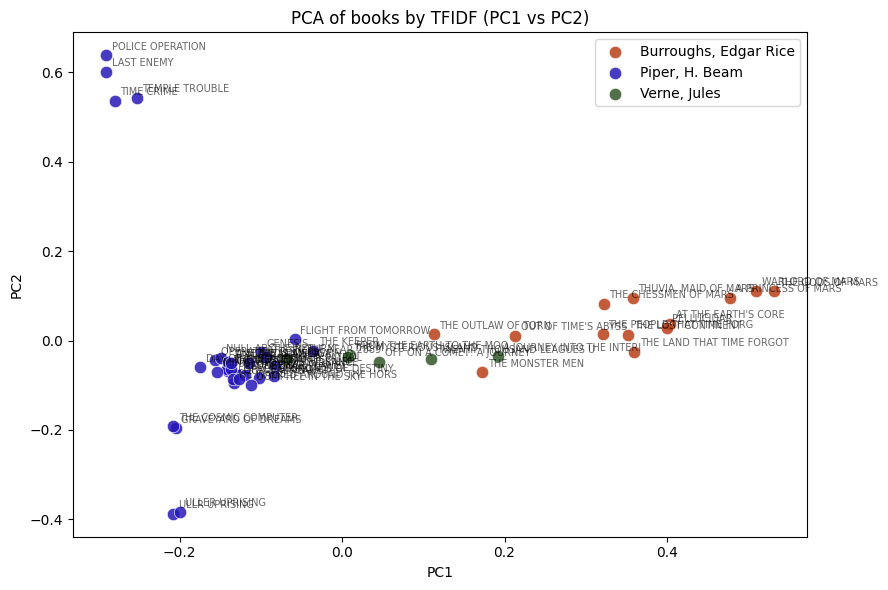

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
merged = DOC_PC.join(LIBRARY[["author", "title", "color"]])

for author, group in merged.groupby("author"):
    ax.scatter(group["PC1"], group["PC2"],
               label=author.title(),
               color=author_colors[author],
               s=80, alpha=0.85, edgecolors="white", linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row["title"][:25],
                    (row["PC1"], row["PC2"]),
                    fontsize=7, alpha=0.6,
                    xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of books by TFIDF (PC1 vs PC2)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/scatter_pca.png", dpi=150)
plt.show()

The PCA scatterplot shows that the novels cluster primarily according to author, indicating that differences in vocabulary and writing style remain detectable even within a shared science fiction genre. Burroughs’s works form a relatively tight grouping, while Piper’s novels display greater internal variation across multiple fictional settings and subgenres. Several outliers are also visible, suggesting that some novels contain vocabulary distributions that differ noticeably from their author’s primary cluster.

## LDA Heatmap

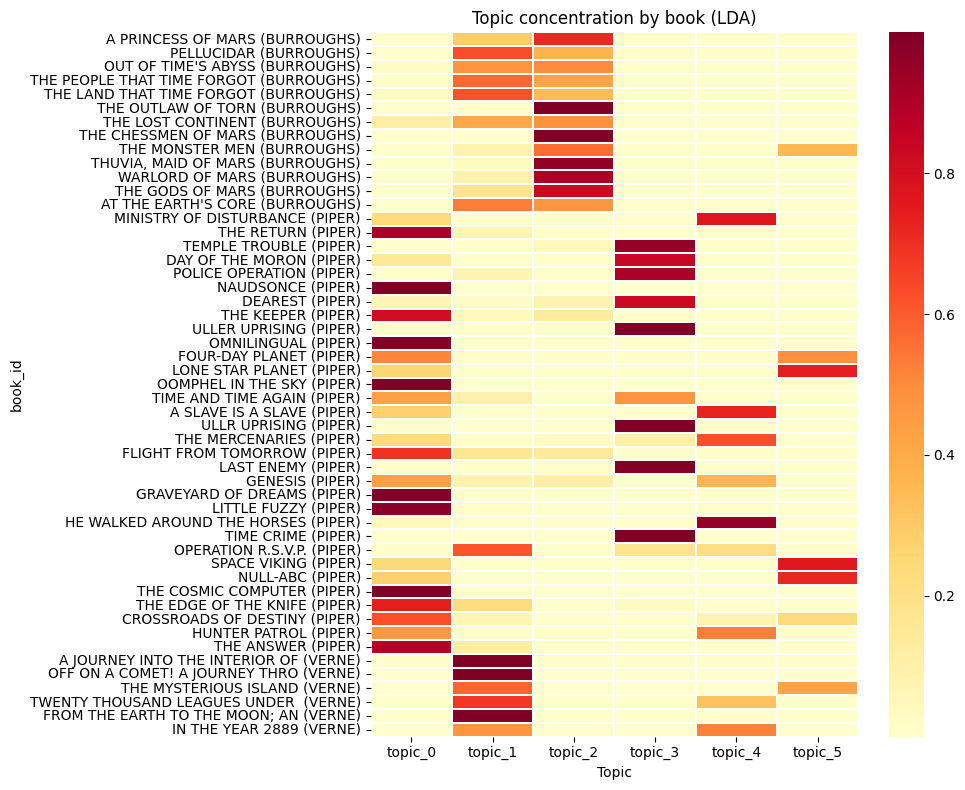

In [10]:
merged_topics = DOC_TOPIC.join(LIBRARY[["author", "title"]])
merged_topics = merged_topics.sort_values("author")

labels = merged_topics["title"].str[:30] + " (" + merged_topics["author"].str.split(",").str[0] + ")"

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    merged_topics.drop(columns=["author", "title"]),
    yticklabels=labels,
    cmap="YlOrRd",
    linewidths=0.3,
    ax=ax
)
ax.set_title("Topic concentration by book (LDA)")
ax.set_xlabel("Topic")
plt.tight_layout()
plt.savefig("../figures/heatmap_topics.png", dpi=150)
plt.show()

The LDA heatmap demonstrates that the topic model successfully identified recurring thematic structures across the corpus. Topic concentrations generally align with author and series boundaries, with Burroughs’s novels emphasizing planetary adventure and combat, Verne’s works focusing on scientific exploration and travel, and Piper’s novels displaying greater thematic diversity. The visualization also reveals smaller subgroupings within each author’s corpus, indicating that the model captures both broad and localized thematic patterns.

## Hierarchial Clustering

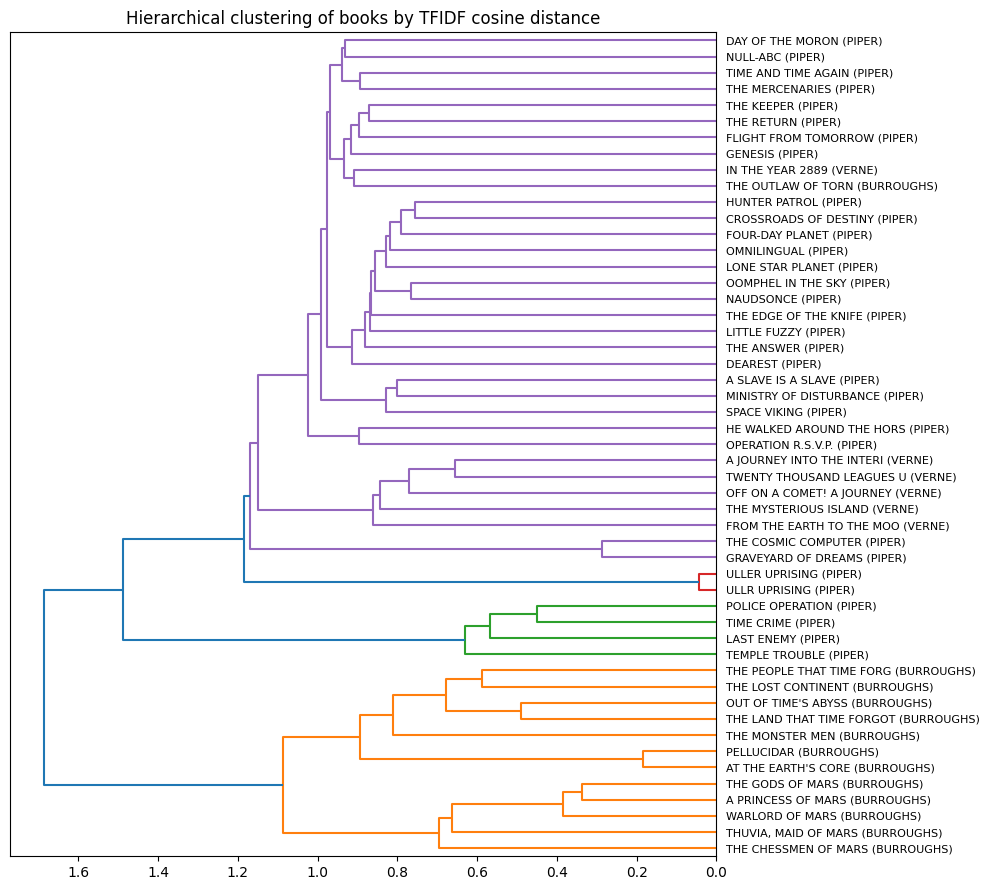

In [11]:
distances = pdist(TFIDF.values, metric="cosine")
linkage_matrix = linkage(distances, method="ward")

labels = [
    f"{LIBRARY.loc[int(i), 'title'][:25]} ({LIBRARY.loc[int(i), 'author'].split(',')[0]})"
    for i in TFIDF.index
]

fig, ax = plt.subplots(figsize=(10, 9))
dendrogram(
    linkage_matrix,
    labels=labels,
    orientation="left",
    leaf_font_size=8,
    ax=ax
)
ax.set_title("Hierarchical clustering of books by TFIDF cosine distance")
plt.tight_layout()
plt.savefig("../figures/cluster_dendrogram.png", dpi=150)
plt.show()

The hierarchical clustering dendrogram reinforces the author-level structure observed in the PCA visualization. Burroughs’s Barsoom novels cluster closely together due to their shared settings, terminology, and recurring characters. Piper’s novels display more variation and split into multiple subgroupings, reflecting the broader thematic diversity of his corpus. Verne’s novels form the most compact overall cluster, suggesting relatively consistent vocabulary usage across his works.

## KDE Sentiment Plot

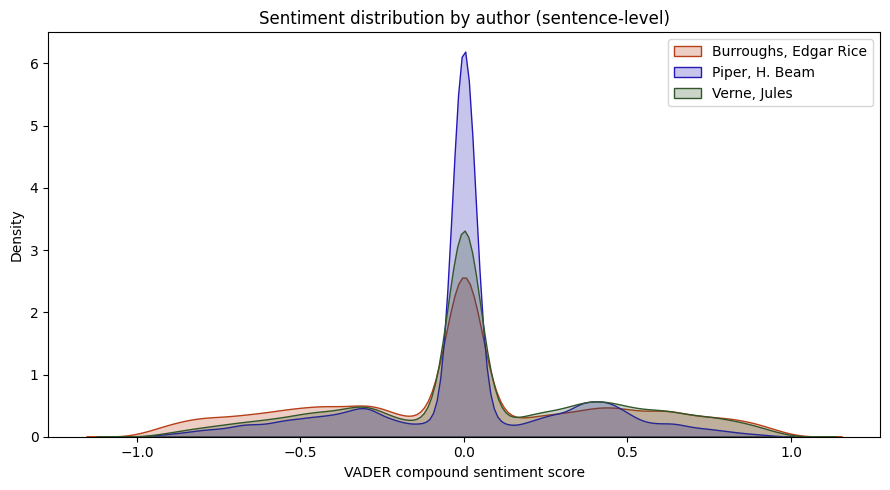

In [12]:
SENT = pd.read_csv("../data/OutputTables/SENT_SENTIMENT.csv")
SENT = SENT.merge(LIBRARY[["author"]].reset_index(), on="book_id")

fig, ax = plt.subplots(figsize=(9, 5))
for author, group in SENT.groupby("author"):
    sns.kdeplot(group["compound"], label=author.title(),
                color=author_colors[author], fill=True, alpha=0.25, ax=ax)

ax.set_xlabel("VADER compound sentiment score")
ax.set_ylabel("Density")
ax.set_title("Sentiment distribution by author (sentence-level)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/kde_sentiment.png", dpi=150)
plt.show()

The KDE sentiment distributions reveal tonal differences between the three authors. Piper’s works remain the most tightly centered around neutral sentiment, suggesting a more restrained and analytical writing style. Burroughs’s novels display the widest emotional range, reflecting the conflict-driven and action-oriented structure of many of his stories. Verne’s works occupy an intermediate position, with slightly more positive sentiment associated with themes of discovery and exploration.